In [3]:
import pandas as pd
from pathlib import Path

raw_path = Path("../data/raw")

accounts = pd.read_csv(raw_path / "ravenstack_accounts.csv")
subscriptions = pd.read_csv(raw_path / "ravenstack_subscriptions.csv")
feature_usage = pd.read_csv(raw_path / "ravenstack_feature_usage.csv")
support_tickets = pd.read_csv(raw_path / "ravenstack_support_tickets.csv")
churn_events = pd.read_csv(raw_path / "ravenstack_churn_events.csv")

In [4]:
tables = {
    "accounts": accounts,
    "subscriptions": subscriptions,
    "feature_usage": feature_usage,
    "support_tickets": support_tickets,
    "churn_events": churn_events
}

for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

accounts: 500 rows, 10 columns
subscriptions: 5000 rows, 14 columns
feature_usage: 25000 rows, 8 columns
support_tickets: 2000 rows, 9 columns
churn_events: 600 rows, 9 columns


In [5]:
for name, df in tables.items():
    print(f"\n{name.upper()} COLUMNS:")
    print(df.columns.tolist())


ACCOUNTS COLUMNS:
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']

SUBSCRIPTIONS COLUMNS:
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']

FEATURE_USAGE COLUMNS:
['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']

SUPPORT_TICKETS COLUMNS:
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']

CHURN_EVENTS COLUMNS:
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


In [6]:
for name, df in tables.items():
    print(f"\n{name.upper()} MISSING VALUES:")
    print(df.isnull().sum())


ACCOUNTS MISSING VALUES:
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64

SUBSCRIPTIONS MISSING VALUES:
subscription_id         0
account_id              0
start_date              0
end_date             4514
plan_tier               0
seats                   0
mrr_amount              0
arr_amount              0
is_trial                0
upgrade_flag            0
downgrade_flag          0
churn_flag              0
billing_frequency       0
auto_renew_flag         0
dtype: int64

FEATURE_USAGE MISSING VALUES:
usage_id               0
subscription_id        0
usage_date             0
feature_name           0
usage_count            0
usage_duration_secs    0
error_count            0
is_beta_feature        0
dtype: int64

SUPPORT_TICKETS MISSING VALUES:
ticket_id                        0
account_id                     

In [7]:
accounts.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


In [8]:
subscriptions.head()

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


In [9]:
feature_usage.head()

,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False


In [10]:
support_tickets.head()

,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False
2,T-d5e12f,A-0f3e88,2024-10-17,2024-10-17 19:00:00,19.0,urgent,93,4.0,False
3,T-dfce9a,A-4c56c9,2024-09-08,2024-09-09 23:00:00,47.0,medium,126,5.0,False
4,T-c59f77,A-6f8ad2,2024-11-30,2024-12-01 02:00:00,26.0,medium,8,NaN,False


In [11]:
churn_events.head()

,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN
2,C-a174be,A-b07346,2024-11-12,budget,0.00,False,False,False,missing features
3,C-accb39,A-1e50e0,2023-11-01,budget,54.94,False,False,False,switched to competitor
4,C-92f889,A-956988,2024-12-30,unknown,0.00,False,True,True,too expensive


In [12]:
print("Accounts:", accounts.shape)
print("Subscriptions:", subscriptions.shape)
print("Feature usage:", feature_usage.shape)
print("Support tickets:", support_tickets.shape)
print("Churn events:", churn_events.shape)


Accounts: (500, 10)
Subscriptions: (5000, 14)
Feature usage: (25000, 8)
Support tickets: (2000, 9)
Churn events: (600, 9)


In [13]:
print("Unique accounts:", accounts["account_id"].nunique())
print("Unique subscription accounts:", subscriptions["account_id"].nunique())
print("Unique support accounts:", support_tickets["account_id"].nunique())
print("Unique churn accounts:", churn_events["account_id"].nunique())

Unique accounts: 500
Unique subscription accounts: 500
Unique support accounts: 492
Unique churn accounts: 352


In [14]:
accounts["churn_flag"].value_counts()

churn_flag
False    390
True     110
Name: count, dtype: int64

In [15]:
total_accounts = accounts["account_id"].nunique()
churned_accounts = accounts[accounts["churn_flag"] == 1]["account_id"].nunique()
churn_rate = churned_accounts / total_accounts * 100

print("Total accounts:", total_accounts)
print("Churned accounts:", churned_accounts)
print(f"Churn rate: {churn_rate:.2f}%")

Total accounts: 500
Churned accounts: 110
Churn rate: 22.00%


## Basic Churn Summary

In [16]:
total_accounts = accounts["account_id"].nunique()

churned_accounts = accounts[accounts["churn_flag"] == 1]["account_id"].nunique()

active_accounts = total_accounts - churned_accounts

churn_rate = churned_accounts / total_accounts * 100

print("Total accounts:", total_accounts)
print("Active accounts:", active_accounts)
print("Churned accounts:", churned_accounts)
print(f"Churn rate: {churn_rate:.2f}%")

Total accounts: 500
Active accounts: 390
Churned accounts: 110
Churn rate: 22.00%


In [17]:
accounts["churn_flag"].value_counts()

churn_flag
False    390
True     110
Name: count, dtype: int64

In [18]:
accounts["churn_flag"].value_counts(normalize=True) * 100

churn_flag
False    78.0
True     22.0
Name: proportion, dtype: float64

### Initial Observation

This section calculates the overall churn rate across all customer accounts. This gives a baseline view of how serious the churn problem is before analyzing churn by plan, industry, usage behavior, and support experience.

### Initial Observation

The dataset shows an overall churn rate of **22%**, meaning about 1 out of every 5 customer accounts has churned. This gives the company a meaningful churn problem to investigate further.

Next, we will analyze churn by plan tier, industry, country, trial status, support experience, and product usage to identify the main drivers of churn.

## Churn by Plan Tier

In [19]:
churn_by_plan = (
    accounts
    .groupby("plan_tier")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_plan["churn_rate_percent"] = churn_by_plan["mean"] * 100

churn_by_plan = churn_by_plan.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_plan = churn_by_plan[
    ["plan_tier", "total_accounts", "churned_accounts", "churn_rate_percent"]
].sort_values("churn_rate_percent", ascending=False)

churn_by_plan

,plan_tier,total_accounts,churned_accounts,churn_rate_percent
1,Enterprise,154,34,22.077922
0,Basic,168,37,22.023810
2,Pro,178,39,21.910112


### Observation

Churn is almost the same across all plan tiers. Enterprise, Basic, and Pro plans all have churn rates around **22%**. This suggests that plan tier alone is not a major driver of churn.

Next, we need to investigate other factors such as industry, country, trial status, support experience, product usage, errors, and downgrades.


## Churn by Industry


In [20]:
churn_by_industry = (
    accounts
    .groupby("industry")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_industry["churn_rate_percent"] = churn_by_industry["mean"] * 100

churn_by_industry = churn_by_industry.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_industry = churn_by_industry[
    ["industry", "total_accounts", "churned_accounts", "churn_rate_percent"]
].sort_values("churn_rate_percent", ascending=False)

churn_by_industry

,industry,total_accounts,churned_accounts,churn_rate_percent
1,DevTools,113,35,30.973451
3,FinTech,112,25,22.321429
4,HealthTech,96,21,21.875000
2,EdTech,79,13,16.455696
0,Cybersecurity,100,16,16.000000


### Observation

Churn varies significantly by industry. DevTools has the highest churn rate at **30.97%**, which is much higher than the overall churn rate of **22%**. 

This suggests that customers in the DevTools segment may have different needs, lower product fit, stronger competition, or a weaker onboarding experience. DevTools should be investigated as a high-risk customer segment.

## Churn by Country

In [21]:
churn_by_country = (
    accounts
    .groupby("country")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_country["churn_rate_percent"] = churn_by_country["mean"] * 100

churn_by_country = churn_by_country.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_country = churn_by_country[
    ["country", "total_accounts", "churned_accounts", "churn_rate_percent"]
].sort_values("churn_rate_percent", ascending=False)

churn_by_country

,country,total_accounts,churned_accounts,churn_rate_percent
2,DE,25,8,32.000000
6,US,291,68,23.367698
3,FR,22,5,22.727273
4,IN,49,10,20.408163
5,UK,58,11,18.965517
1,CA,23,4,17.391304
0,AU,32,4,12.500000


### Observation

Germany (`DE`) has the highest churn rate at **32%**, which is significantly higher than the overall churn rate of **22%**. However, Germany only has **25 accounts**, so this finding should be treated carefully because the sample size is smaller.

The US has a churn rate of **23.37%** and has the largest customer base with **291 accounts**, making it more important from a business impact perspective.

This suggests two possible priorities:
- Germany may need investigation due to high churn rate.
- The US may need attention due to higher total churn volume.

## Churn by Trial Status

In [22]:
churn_by_trial = (
    accounts
    .groupby("is_trial")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_trial["churn_rate_percent"] = churn_by_trial["mean"] * 100

churn_by_trial = churn_by_trial.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_trial = churn_by_trial[
    ["is_trial", "total_accounts", "churned_accounts", "churn_rate_percent"]
].sort_values("churn_rate_percent", ascending=False)

churn_by_trial

,is_trial,total_accounts,churned_accounts,churn_rate_percent
1,True,97,25,25.773196
0,False,403,85,21.091811


### Observation

Trial customers have a churn rate of **25.77%**, compared to **21.09%** for non-trial customers. This suggests that trial users are more likely to leave, possibly because they do not reach product value quickly enough during onboarding.

This is an early sign that the company may need stronger trial onboarding, better activation emails, or clearer guidance toward key product features.

## Churn by Billing Frequency

In [23]:
churn_by_billing = (
    subscriptions
    .groupby("billing_frequency")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_billing["churn_rate_percent"] = churn_by_billing["mean"] * 100

churn_by_billing = churn_by_billing.rename(columns={
    "count": "total_subscriptions",
    "sum": "churned_subscriptions"
})

churn_by_billing = churn_by_billing[
    ["billing_frequency", "total_subscriptions", "churned_subscriptions", "churn_rate_percent"]
].sort_values("churn_rate_percent", ascending=False)

churn_by_billing

,billing_frequency,total_subscriptions,churned_subscriptions,churn_rate_percent
0,annual,2461,247,10.036570
1,monthly,2539,239,9.413155


### Observation

Churn rates are very similar across billing frequencies. Annual subscriptions have a churn rate of **10.04%**, while monthly subscriptions have a churn rate of **9.41%**.

This suggests that billing frequency alone is not a major churn driver in this dataset. We should continue investigating stronger behavioral signals such as downgrades, support tickets, satisfaction scores, product usage, and error counts.

## Churn by Downgrade Status

In [24]:
churn_by_downgrade = (
    subscriptions
    .groupby("downgrade_flag")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_downgrade["churn_rate_percent"] = churn_by_downgrade["mean"] * 100

churn_by_downgrade = churn_by_downgrade.rename(columns={
    "count": "total_subscriptions",
    "sum": "churned_subscriptions"
})

churn_by_downgrade = churn_by_downgrade[
    ["downgrade_flag", "total_subscriptions", "churned_subscriptions", "churn_rate_percent"]
].sort_values("churn_rate_percent", ascending=False)

churn_by_downgrade

,downgrade_flag,total_subscriptions,churned_subscriptions,churn_rate_percent
1,True,218,25,11.467890
0,False,4782,461,9.640318


### Observation

Subscriptions with a downgrade have a churn rate of **11.47%**, compared to **9.64%** for subscriptions without a downgrade.

This suggests that downgrades may be an early warning signal, but the difference is not large enough to explain churn by itself. Downgrade behavior should be analyzed together with other factors such as low usage, support tickets, satisfaction score, and error count.

## Churn by Upgrade Status

In [25]:
churn_by_upgrade = (
    subscriptions
    .groupby("upgrade_flag")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_upgrade["churn_rate_percent"] = churn_by_upgrade["mean"] * 100

churn_by_upgrade = churn_by_upgrade.rename(columns={
    "count": "total_subscriptions",
    "sum": "churned_subscriptions"
})

churn_by_upgrade = churn_by_upgrade[
    ["upgrade_flag", "total_subscriptions", "churned_subscriptions", "churn_rate_percent"]
].sort_values("churn_rate_percent", ascending=False)

churn_by_upgrade

,upgrade_flag,total_subscriptions,churned_subscriptions,churn_rate_percent
0,False,4471,440,9.841199
1,True,529,46,8.695652


### Observation

Subscriptions with an upgrade have a churn rate of **8.70%**, compared to **9.84%** for subscriptions without an upgrade.

This suggests that upgraded customers may be slightly more retained, possibly because they receive more value from the product. However, the difference is small, so upgrade status alone is not a major churn driver.

## Churn by Support Ticket Volume

In [26]:
support_summary = (
    support_tickets
    .groupby("account_id")
    .agg(
        total_tickets=("ticket_id", "count"),
        avg_resolution_time_hours=("resolution_time_hours", "mean"),
        avg_first_response_time_minutes=("first_response_time_minutes", "mean"),
        avg_satisfaction_score=("satisfaction_score", "mean"),
        escalated_tickets=("escalation_flag", "sum")
    )
    .reset_index()
)

accounts_support = accounts.merge(
    support_summary,
    on="account_id",
    how="left"
)

accounts_support["total_tickets"] = accounts_support["total_tickets"].fillna(0)
accounts_support["escalated_tickets"] = accounts_support["escalated_tickets"].fillna(0)

In [27]:
accounts_support["ticket_bucket"] = pd.cut(
    accounts_support["total_tickets"],
    bins=[-1, 0, 2, 5, float("inf")],
    labels=["0 tickets", "1-2 tickets", "3-5 tickets", "6+ tickets"]
)

churn_by_ticket_bucket = (
    accounts_support
    .groupby("ticket_bucket")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_ticket_bucket["churn_rate_percent"] = churn_by_ticket_bucket["mean"] * 100

churn_by_ticket_bucket = churn_by_ticket_bucket.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_ticket_bucket = churn_by_ticket_bucket[
    ["ticket_bucket", "total_accounts", "churned_accounts", "churn_rate_percent"]
]

churn_by_ticket_bucket

,ticket_bucket,total_accounts,churned_accounts,churn_rate_percent
0,0 tickets,8,2,25.000000
1,1-2 tickets,104,26,25.000000
2,3-5 tickets,292,59,20.205479
3,6+ tickets,96,23,23.958333


### Observation

Support ticket volume alone does not show a strong or consistent relationship with churn. Accounts with **1–2 tickets** had a churn rate of **25%**, while accounts with **3–5 tickets** had a lower churn rate of **20.21%**. Accounts with **6+ tickets** had a churn rate of **23.96%**.

This suggests that the number of support tickets by itself may not explain churn. A better next step is to analyze the quality of the support experience, such as satisfaction score, first response time, resolution time, and escalations.

## Churn by Support Satisfaction Score

In [28]:
# Create support summary per account
support_summary = (
    support_tickets
    .groupby("account_id")
    .agg(
        total_tickets=("ticket_id", "count"),
        avg_resolution_time_hours=("resolution_time_hours", "mean"),
        avg_first_response_time_minutes=("first_response_time_minutes", "mean"),
        avg_satisfaction_score=("satisfaction_score", "mean"),
        escalated_tickets=("escalation_flag", "sum")
    )
    .reset_index()
)

# Merge support metrics with account-level churn
accounts_support = accounts.merge(
    support_summary,
    on="account_id",
    how="left"
)

# Create satisfaction score buckets
accounts_support["satisfaction_bucket"] = pd.cut(
    accounts_support["avg_satisfaction_score"],
    bins=[0, 2, 3, 4, 5],
    labels=["Low satisfaction", "Medium satisfaction", "Good satisfaction", "High satisfaction"],
    include_lowest=True
)

churn_by_satisfaction = (
    accounts_support
    .dropna(subset=["satisfaction_bucket"])
    .groupby("satisfaction_bucket")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_satisfaction["churn_rate_percent"] = churn_by_satisfaction["mean"] * 100

churn_by_satisfaction = churn_by_satisfaction.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_satisfaction = churn_by_satisfaction[
    ["satisfaction_bucket", "total_accounts", "churned_accounts", "churn_rate_percent"]
]

churn_by_satisfaction

,satisfaction_bucket,total_accounts,churned_accounts,churn_rate_percent
0,Medium satisfaction,61,11,18.032787
1,Good satisfaction,251,57,22.709163
2,High satisfaction,154,34,22.077922


### Observation

Average support satisfaction score does not show a clear negative relationship with churn in this dataset. Accounts with medium satisfaction had a churn rate of **18.03%**, while accounts with good and high satisfaction had churn rates around **22%**.

This suggests that satisfaction score alone may not be a strong churn driver. Since support ticket volume and satisfaction score do not clearly explain churn, the next step is to analyze other support-related signals such as escalation rate, first response time, and resolution time.

In [29]:
accounts_support["has_escalation"] = accounts_support["escalated_tickets"] > 0

churn_by_escalation = (
    accounts_support
    .groupby("has_escalation")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_escalation["churn_rate_percent"] = churn_by_escalation["mean"] * 100

churn_by_escalation = churn_by_escalation.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_escalation = churn_by_escalation[
    ["has_escalation", "total_accounts", "churned_accounts", "churn_rate_percent"]
]

churn_by_escalation

,has_escalation,total_accounts,churned_accounts,churn_rate_percent
0,False,409,87,21.271394
1,True,91,23,25.274725


### Observation

Accounts with at least one escalated support ticket had a churn rate of **25.27%**, compared to **21.27%** for accounts without escalations.

This suggests that escalations may be a moderate warning signal for churn. Customers who require escalated support may be experiencing more serious product issues or unresolved pain points, making them more likely to leave.

## Churn by First Response Time

In [30]:
accounts_support["response_time_bucket"] = pd.cut(
    accounts_support["avg_first_response_time_minutes"],
    bins=[0, 30, 60, 120, float("inf")],
    labels=["0-30 min", "31-60 min", "61-120 min", "120+ min"],
    include_lowest=True
)

churn_by_response_time = (
    accounts_support
    .dropna(subset=["response_time_bucket"])
    .groupby("response_time_bucket")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_response_time["churn_rate_percent"] = churn_by_response_time["mean"] * 100

churn_by_response_time = churn_by_response_time.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_response_time = churn_by_response_time[
    ["response_time_bucket", "total_accounts", "churned_accounts", "churn_rate_percent"]
]

churn_by_response_time

,response_time_bucket,total_accounts,churned_accounts,churn_rate_percent
0,0-30 min,10,2,20.000000
1,31-60 min,61,16,26.229508
2,61-120 min,362,79,21.823204
3,120+ min,59,11,18.644068


### Observation

Average first response time does not show a clear linear relationship with churn. Accounts with a **31–60 minute** average response time had the highest churn rate at **26.23%**, while accounts with **120+ minute** response times had a lower churn rate of **18.64%**.

This suggests that first response time alone is not a strong churn driver in this dataset. Support escalations appear to be a more useful warning signal than response time.

In [31]:
accounts_support["resolution_time_bucket"] = pd.cut(
    accounts_support["avg_resolution_time_hours"],
    bins=[0, 12, 24, 48, float("inf")],
    labels=["0-12 hrs", "13-24 hrs", "25-48 hrs", "48+ hrs"],
    include_lowest=True
)

churn_by_resolution_time = (
    accounts_support
    .dropna(subset=["resolution_time_bucket"])
    .groupby("resolution_time_bucket")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_resolution_time["churn_rate_percent"] = churn_by_resolution_time["mean"] * 100

churn_by_resolution_time = churn_by_resolution_time.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_resolution_time = churn_by_resolution_time[
    ["resolution_time_bucket", "total_accounts", "churned_accounts", "churn_rate_percent"]
]

churn_by_resolution_time

,resolution_time_bucket,total_accounts,churned_accounts,churn_rate_percent
0,0-12 hrs,8,3,37.500000
1,13-24 hrs,57,12,21.052632
2,25-48 hrs,355,78,21.971831
3,48+ hrs,72,15,20.833333


### Observation

Average resolution time does not show a clear relationship with churn. The **0–12 hour** group has the highest churn rate at **37.50%**, but this group only contains **8 accounts**, so the result may not be reliable due to small sample size.

The larger groups, including **13–24 hours**, **25–48 hours**, and **48+ hours**, all have churn rates around **21–22%**, close to the overall churn rate of **22%**.

This suggests that resolution time alone is not a strong churn driver in this dataset. Among support-related variables, ticket escalation appears to be the strongest warning signal so far.

### Support Experience Summary

Support ticket volume, satisfaction score, first response time, and resolution time do not show strong standalone relationships with churn. However, accounts with escalated tickets have a higher churn rate (**25.27%**) than accounts without escalations (**21.27%**).

This suggests that support escalation may be a useful churn warning signal, while general support activity alone is not enough to explain why customers leave.

## Product Usage Summary

In [32]:
usage_with_accounts = feature_usage.merge(
    subscriptions[["subscription_id", "account_id"]],
    on="subscription_id",
    how="left"
)

usage_summary = (
    usage_with_accounts
    .groupby("account_id")
    .agg(
        total_usage_count=("usage_count", "sum"),
        avg_usage_count=("usage_count", "mean"),
        total_usage_duration_secs=("usage_duration_secs", "sum"),
        avg_usage_duration_secs=("usage_duration_secs", "mean"),
        total_errors=("error_count", "sum"),
        avg_errors=("error_count", "mean"),
        unique_features_used=("feature_name", "nunique"),
        beta_feature_usage=("is_beta_feature", "sum")
    )
    .reset_index()
)

accounts_usage = accounts.merge(
    usage_summary,
    on="account_id",
    how="left"
)

accounts_usage[[
    "total_usage_count",
    "avg_usage_count",
    "total_usage_duration_secs",
    "avg_usage_duration_secs",
    "total_errors",
    "avg_errors",
    "unique_features_used",
    "beta_feature_usage"
]] = accounts_usage[[
    "total_usage_count",
    "avg_usage_count",
    "total_usage_duration_secs",
    "avg_usage_duration_secs",
    "total_errors",
    "avg_errors",
    "unique_features_used",
    "beta_feature_usage"
]].fillna(0)

accounts_usage.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,total_usage_count,avg_usage_count,total_usage_duration_secs,avg_usage_duration_secs,total_errors,avg_errors,unique_features_used,beta_feature_usage
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,535,9.727273,152339,2769.800000,38,0.690909,27,4
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,355,10.142857,101136,2889.600000,14,0.400000,23,2
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,821,9.891566,251210,3026.626506,48,0.578313,34,5
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False,382,9.317073,102528,2500.682927,21,0.512195,26,5
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,579,9.982759,215779,3720.327586,31,0.534483,32,4


## Churn by Product Usage Level

In [33]:
accounts_usage["usage_bucket"] = pd.qcut(
    accounts_usage["total_usage_count"],
    q=4,
    labels=["Low usage", "Medium-low usage", "Medium-high usage", "High usage"]
)

churn_by_usage = (
    accounts_usage
    .groupby("usage_bucket")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_usage["churn_rate_percent"] = churn_by_usage["mean"] * 100

churn_by_usage = churn_by_usage.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_usage = churn_by_usage[
    ["usage_bucket", "total_accounts", "churned_accounts", "churn_rate_percent"]
]

churn_by_usage

,usage_bucket,total_accounts,churned_accounts,churn_rate_percent
0,Low usage,126,22,17.460317
1,Medium-low usage,124,25,20.161290
2,Medium-high usage,125,36,28.800000
3,High usage,125,27,21.600000


### Observation

Total product usage does not show a simple relationship with churn. Low-usage accounts had the lowest churn rate at **17.46%**, while medium-high usage accounts had the highest churn rate at **28.80%**.

This suggests that usage volume alone may not explain churn. Some customers may be using the product frequently but still leaving due to friction, errors, missing features, poor fit, or support issues.

Next, we should analyze feature adoption and product errors to understand whether customers are experiencing product value or product friction.

In [34]:
accounts_usage["feature_adoption_bucket"] = pd.qcut(
    accounts_usage["unique_features_used"],
    q=4,
    labels=["Low adoption", "Medium-low adoption", "Medium-high adoption", "High adoption"]
)

churn_by_feature_adoption = (
    accounts_usage
    .groupby("feature_adoption_bucket")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_feature_adoption["churn_rate_percent"] = churn_by_feature_adoption["mean"] * 100

churn_by_feature_adoption = churn_by_feature_adoption.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_feature_adoption = churn_by_feature_adoption[
    ["feature_adoption_bucket", "total_accounts", "churned_accounts", "churn_rate_percent"]
]

churn_by_feature_adoption

,feature_adoption_bucket,total_accounts,churned_accounts,churn_rate_percent
0,Low adoption,127,23,18.110236
1,Medium-low adoption,125,26,20.800000
2,Medium-high adoption,157,42,26.751592
3,High adoption,91,19,20.879121


### Observation

Feature adoption does not show a simple pattern where lower adoption leads to higher churn. Accounts with **medium-high feature adoption** had the highest churn rate at **26.75%**, while low-adoption accounts had a lower churn rate of **18.11%**.

This suggests that churn may not be caused by lack of usage alone. Some customers may be actively exploring multiple features but still leaving due to product friction, errors, missing functionality, or unmet expectations.

The next step is to analyze product errors to see whether active users are experiencing friction that could lead to churn.

In [35]:
accounts_usage["error_bucket"] = pd.qcut(
    accounts_usage["total_errors"],
    q=4,
    labels=["Low errors", "Medium-low errors", "Medium-high errors", "High errors"]
)

churn_by_errors = (
    accounts_usage
    .groupby("error_bucket")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

churn_by_errors["churn_rate_percent"] = churn_by_errors["mean"] * 100

churn_by_errors = churn_by_errors.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

churn_by_errors = churn_by_errors[
    ["error_bucket", "total_accounts", "churned_accounts", "churn_rate_percent"]
]

churn_by_errors

,error_bucket,total_accounts,churned_accounts,churn_rate_percent
0,Low errors,131,29,22.137405
1,Medium-low errors,133,26,19.548872
2,Medium-high errors,117,30,25.641026
3,High errors,119,25,21.008403


### Observation

Product errors show a mild churn signal, but not a clear linear pattern. Accounts in the **medium-high errors** group had the highest churn rate at **25.64%**, while the high-error group had a lower churn rate of **21.01%**.

This suggests that product friction may contribute to churn for some customers, but total error count alone does not fully explain why customers leave. A better next step is to combine product usage, feature adoption, errors, industry, trial status, and support escalations into a churn risk profile.

## Findings Summary So Far

The overall churn rate is **22%**.

The strongest segment-level churn signals so far are:

- **Industry:** DevTools customers have the highest churn rate at **30.97%**.
- **Country:** Germany has the highest churn rate at **32%**, but the sample size is small with only 25 accounts.
- **Trial status:** Trial customers churn at **25.77%**, compared to **21.09%** for non-trial customers.
- **Support escalation:** Accounts with escalated tickets churn at **25.27%**, compared to **21.27%** for accounts without escalations.
- **Product behavior:** Medium-high usage, medium-high feature adoption, and medium-high error groups show elevated churn, but product usage and errors do not show simple linear patterns.

The weakest churn signals so far are:

- Plan tier
- Billing frequency
- Upgrade status
- Downgrade status
- Ticket volume
- Satisfaction score
- First response time
- Resolution time

Based on the current analysis, churn appears to be more segment-driven and friction-driven than pricing-plan-driven.

In [36]:
churn_reasons = (
    churn_events
    .groupby("reason_code")
    .agg(
        churn_events=("churn_event_id", "count"),
        unique_accounts=("account_id", "nunique"),
        avg_refund_amount=("refund_amount_usd", "mean")
    )
    .reset_index()
    .sort_values("churn_events", ascending=False)
)

churn_reasons

,reason_code,churn_events,unique_accounts,avg_refund_amount
2,features,114,104,16.718421
0,budget,104,94,11.995577
4,support,104,95,11.727308
5,unknown,95,86,18.340947
1,competitor,92,79,13.081848
3,pricing,91,86,14.651099


### Observation

The most common churn reason is **features**, with **114 churn events** across **104 unique accounts**. This suggests that missing features or unmet product needs may be a major reason customers leave.

Budget and support are also common churn reasons, each with **104 churn events**, indicating that churn is not caused by only one issue. Instead, customers may be leaving because of a combination of product gaps, financial constraints, and support-related friction.

This finding strengthens the earlier product usage insight: some customers are actively using or exploring the product, but may still churn if the product does not meet their expectations or required use cases.

## Churn Reasons by Industry

In [37]:
churn_reasons_by_industry = (
    churn_events
    .merge(accounts[["account_id", "industry"]], on="account_id", how="left")
    .groupby(["industry", "reason_code"])
    .agg(
        churn_events=("churn_event_id", "count"),
        unique_accounts=("account_id", "nunique")
    )
    .reset_index()
    .sort_values(["industry", "churn_events"], ascending=[True, False])
)

churn_reasons_by_industry

,industry,reason_code,churn_events,unique_accounts
5,Cybersecurity,unknown,27,24
0,Cybersecurity,budget,22,21
2,Cybersecurity,features,20,19
4,Cybersecurity,support,20,18
1,Cybersecurity,competitor,17,15
3,Cybersecurity,pricing,14,14
6,DevTools,budget,27,25
10,DevTools,support,27,23
8,DevTools,features,26,24
7,DevTools,competitor,25,20


### Observation

DevTools has the highest overall churn rate, but its churn reasons are spread across multiple categories. Budget and support are the top reasons with **27 churn events each**, followed closely by features with **26 churn events** and competitor with **25 churn events**.

This suggests that DevTools churn is not driven by one single issue. Instead, DevTools customers may be experiencing a combination of value concerns, support friction, missing features, and competitive alternatives.

This segment should be prioritized for deeper investigation because it has both a high churn rate and multiple active churn drivers.

## Churn Risk Profile

In [38]:
# Combine account, support, and usage-level signals
risk_df = accounts_usage.merge(
    accounts_support[["account_id", "has_escalation"]],
    on="account_id",
    how="left"
)

risk_df["has_escalation"] = risk_df["has_escalation"].fillna(False)

# Create simple churn risk score based on findings so far
risk_df["risk_score"] = 0

risk_df.loc[risk_df["industry"] == "DevTools", "risk_score"] += 2
risk_df.loc[risk_df["country"] == "DE", "risk_score"] += 1
risk_df.loc[risk_df["is_trial"] == True, "risk_score"] += 1
risk_df.loc[risk_df["has_escalation"] == True, "risk_score"] += 1
risk_df.loc[risk_df["total_errors"] >= risk_df["total_errors"].quantile(0.50), "risk_score"] += 1
risk_df.loc[risk_df["unique_features_used"] >= risk_df["unique_features_used"].quantile(0.50), "risk_score"] += 1

risk_df["risk_segment"] = pd.cut(
    risk_df["risk_score"],
    bins=[-1, 1, 3, 10],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_summary = (
    risk_df
    .groupby("risk_segment")["churn_flag"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

risk_summary["churn_rate_percent"] = risk_summary["mean"] * 100

risk_summary = risk_summary.rename(columns={
    "count": "total_accounts",
    "sum": "churned_accounts"
})

risk_summary = risk_summary[
    ["risk_segment", "total_accounts", "churned_accounts", "churn_rate_percent"]
]

risk_summary

,risk_segment,total_accounts,churned_accounts,churn_rate_percent
0,Low Risk,180,27,15.000000
1,Medium Risk,258,63,24.418605
2,High Risk,62,20,32.258065


### Observation

The churn risk profile shows a clear increase in churn rate as risk level increases. Low-risk accounts have a churn rate of **15.00%**, medium-risk accounts have a churn rate of **24.42%**, and high-risk accounts have a churn rate of **32.26%**.

This confirms that combining multiple churn signals produces a more useful customer risk segmentation than looking at individual factors alone. The high-risk group represents only **62 accounts**, but has the highest churn rate, making it a strong target for proactive retention efforts.

## Churn Playbook

| Risk Segment | Trigger Signals | Recommended Action | Business Owner |
|---|---|---|---|
| Low Risk | Low risk score, no major warning signals | Continue standard lifecycle emails and product education | Marketing |
| Medium Risk | Trial user, support escalation, moderate product friction, or higher feature exploration | Send targeted onboarding tips, feature guidance, and check-in email | Customer Success |
| High Risk | DevTools customer, trial user, support escalation, high errors, or multiple risk signals | Assign customer success outreach, review support history, offer feature-specific guidance, and prioritize product feedback | Customer Success / Product |

### Playbook Recommendation

The company should prioritize high-risk accounts for proactive retention. High-risk accounts show a churn rate of **32.26%**, compared to only **15.00%** for low-risk accounts.

Recommended actions include personalized onboarding, support escalation review, feature education, and product feedback collection, especially for DevTools customers and trial users.

## Export Processed Customer Churn Dataset

In [39]:
# Recreate support summary
support_summary = (
    support_tickets
    .groupby("account_id")
    .agg(
        total_tickets=("ticket_id", "count"),
        avg_resolution_time_hours=("resolution_time_hours", "mean"),
        avg_first_response_time_minutes=("first_response_time_minutes", "mean"),
        avg_satisfaction_score=("satisfaction_score", "mean"),
        escalated_tickets=("escalation_flag", "sum")
    )
    .reset_index()
)

accounts_support = accounts.merge(
    support_summary,
    on="account_id",
    how="left"
)

accounts_support["total_tickets"] = accounts_support["total_tickets"].fillna(0)
accounts_support["escalated_tickets"] = accounts_support["escalated_tickets"].fillna(0)
accounts_support["has_escalation"] = accounts_support["escalated_tickets"] > 0


# Recreate usage summary
usage_with_accounts = feature_usage.merge(
    subscriptions[["subscription_id", "account_id"]],
    on="subscription_id",
    how="left"
)

usage_summary = (
    usage_with_accounts
    .groupby("account_id")
    .agg(
        total_usage_count=("usage_count", "sum"),
        avg_usage_count=("usage_count", "mean"),
        total_usage_duration_secs=("usage_duration_secs", "sum"),
        avg_usage_duration_secs=("usage_duration_secs", "mean"),
        total_errors=("error_count", "sum"),
        avg_errors=("error_count", "mean"),
        unique_features_used=("feature_name", "nunique"),
        beta_feature_usage=("is_beta_feature", "sum")
    )
    .reset_index()
)

accounts_usage = accounts.merge(
    usage_summary,
    on="account_id",
    how="left"
)

usage_cols = [
    "total_usage_count",
    "avg_usage_count",
    "total_usage_duration_secs",
    "avg_usage_duration_secs",
    "total_errors",
    "avg_errors",
    "unique_features_used",
    "beta_feature_usage"
]

accounts_usage[usage_cols] = accounts_usage[usage_cols].fillna(0)


# Recreate risk_df
risk_df = accounts_usage.merge(
    accounts_support[["account_id", "has_escalation"]],
    on="account_id",
    how="left"
)

risk_df["has_escalation"] = risk_df["has_escalation"].fillna(False)

risk_df["risk_score"] = 0

risk_df.loc[risk_df["industry"] == "DevTools", "risk_score"] += 2
risk_df.loc[risk_df["country"] == "DE", "risk_score"] += 1
risk_df.loc[risk_df["is_trial"] == True, "risk_score"] += 1
risk_df.loc[risk_df["has_escalation"] == True, "risk_score"] += 1
risk_df.loc[risk_df["total_errors"] >= risk_df["total_errors"].quantile(0.50), "risk_score"] += 1
risk_df.loc[risk_df["unique_features_used"] >= risk_df["unique_features_used"].quantile(0.50), "risk_score"] += 1

risk_df["risk_segment"] = pd.cut(
    risk_df["risk_score"],
    bins=[-1, 1, 3, 10],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

risk_df.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,...,avg_usage_count,total_usage_duration_secs,avg_usage_duration_secs,total_errors,avg_errors,unique_features_used,beta_feature_usage,has_escalation,risk_score,risk_segment
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,9.727273,152339,2769.800000,38,0.690909,27,4,False,1,Low Risk
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,...,10.142857,101136,2889.600000,14,0.400000,23,2,False,0,Low Risk
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,...,9.891566,251210,3026.626506,48,0.578313,34,5,False,4,High Risk
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False,...,9.317073,102528,2500.682927,21,0.512195,26,5,False,1,Low Risk
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,...,9.982759,215779,3720.327586,31,0.534483,32,4,True,3,Medium Risk


In [40]:
processed_churn_df = risk_df.copy()

processed_churn_df = processed_churn_df[
    [
        "account_id",
        "account_name",
        "industry",
        "country",
        "signup_date",
        "referral_source",
        "plan_tier",
        "seats",
        "is_trial",
        "churn_flag",
        "total_usage_count",
        "avg_usage_count",
        "total_usage_duration_secs",
        "avg_usage_duration_secs",
        "total_errors",
        "avg_errors",
        "unique_features_used",
        "beta_feature_usage",
        "has_escalation",
        "risk_score",
        "risk_segment"
    ]
]

processed_churn_df.to_csv("../data/processed/customer_churn_risk_profile.csv", index=False)

processed_churn_df.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,...,avg_usage_count,total_usage_duration_secs,avg_usage_duration_secs,total_errors,avg_errors,unique_features_used,beta_feature_usage,has_escalation,risk_score,risk_segment
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,9.727273,152339,2769.800000,38,0.690909,27,4,False,1,Low Risk
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,...,10.142857,101136,2889.600000,14,0.400000,23,2,False,0,Low Risk
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,...,9.891566,251210,3026.626506,48,0.578313,34,5,False,4,High Risk
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False,...,9.317073,102528,2500.682927,21,0.512195,26,5,False,1,Low Risk
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,...,9.982759,215779,3720.327586,31,0.534483,32,4,True,3,Medium Risk


In [41]:
import os
os.listdir("../data/processed")

['customer_churn_risk_profile.csv']

In [42]:
processed_check = pd.read_csv("../data/processed/customer_churn_risk_profile.csv")

processed_check.head()

,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,...,avg_usage_count,total_usage_duration_secs,avg_usage_duration_secs,total_errors,avg_errors,unique_features_used,beta_feature_usage,has_escalation,risk_score,risk_segment
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False,...,9.727273,152339,2769.800000,38,0.690909,27,4,False,1,Low Risk
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True,...,10.142857,101136,2889.600000,14,0.400000,23,2,False,0,Low Risk
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False,...,9.891566,251210,3026.626506,48,0.578313,34,5,False,4,High Risk
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False,...,9.317073,102528,2500.682927,21,0.512195,26,5,False,1,Low Risk
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True,...,9.982759,215779,3720.327586,31,0.534483,32,4,True,3,Medium Risk


In [43]:
processed_check.shape

(500, 21)

## Churn Visualizations

In [44]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


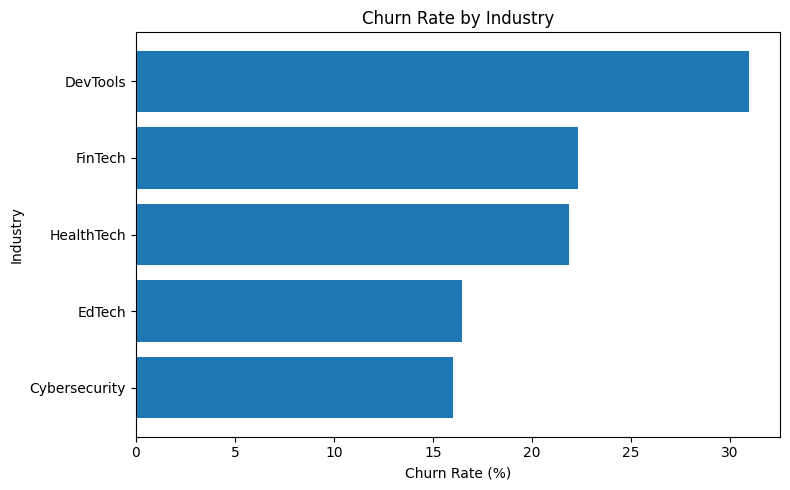

In [45]:
churn_by_industry_plot = churn_by_industry.sort_values("churn_rate_percent", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(churn_by_industry_plot["industry"], churn_by_industry_plot["churn_rate_percent"])
plt.xlabel("Churn Rate (%)")
plt.ylabel("Industry")
plt.title("Churn Rate by Industry")
plt.tight_layout()
plt.show()

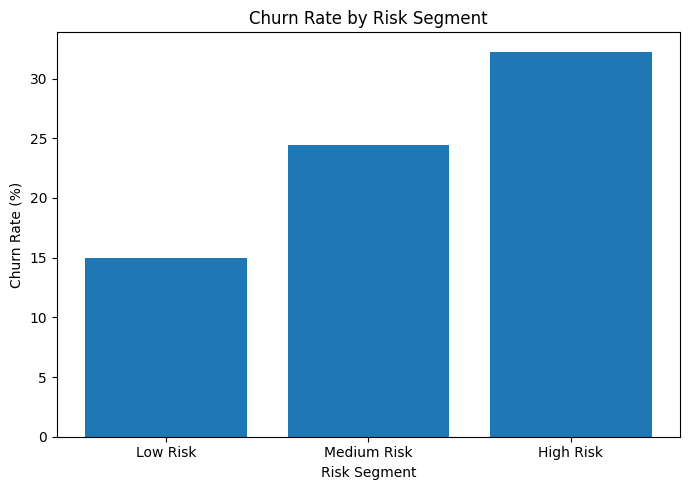

In [46]:
risk_summary_plot = risk_summary.copy()

plt.figure(figsize=(7, 5))
plt.bar(risk_summary_plot["risk_segment"].astype(str), risk_summary_plot["churn_rate_percent"])
plt.xlabel("Risk Segment")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Risk Segment")
plt.tight_layout()
plt.show()

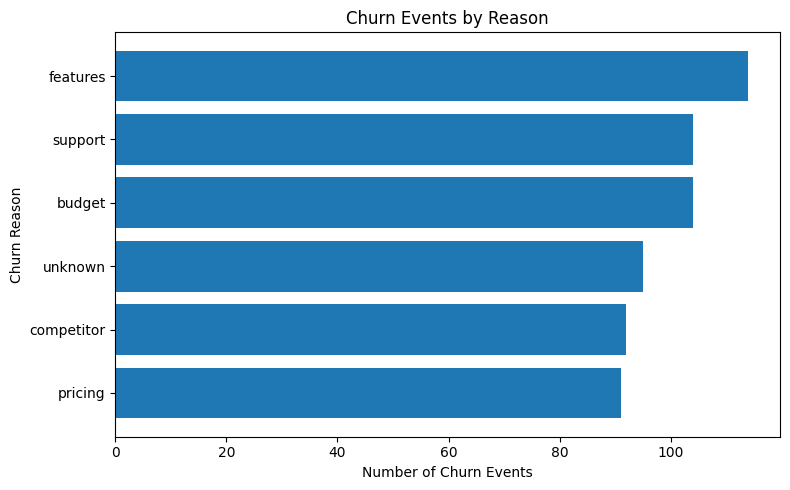

In [47]:
churn_reasons_plot = churn_reasons.sort_values("churn_events", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(churn_reasons_plot["reason_code"], churn_reasons_plot["churn_events"])
plt.xlabel("Number of Churn Events")
plt.ylabel("Churn Reason")
plt.title("Churn Events by Reason")
plt.tight_layout()
plt.show()

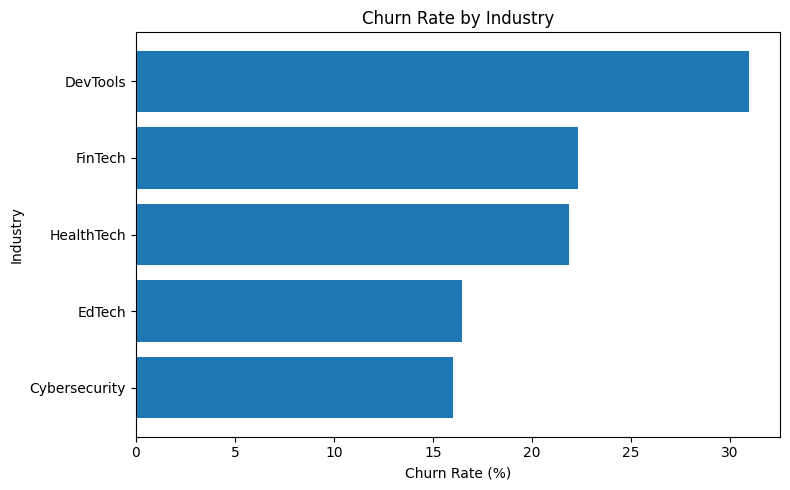

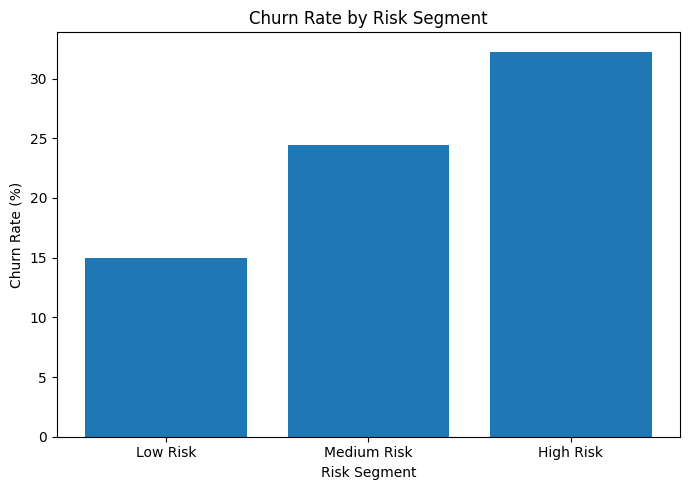

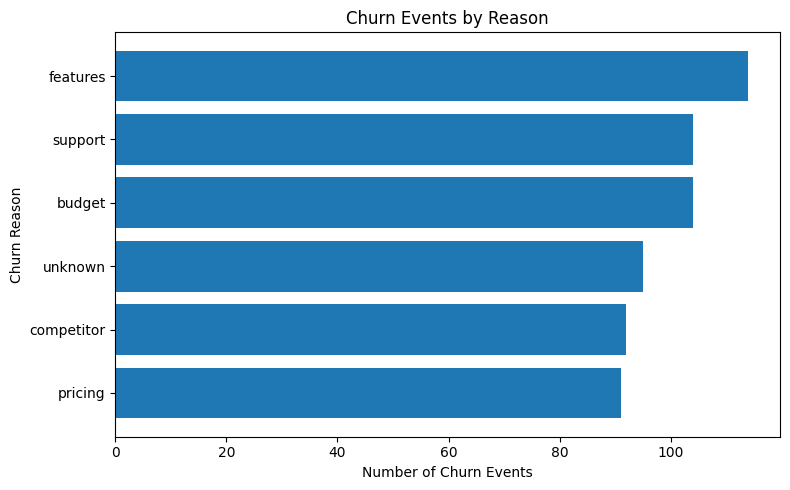

In [48]:
# Churn by Industry
plt.figure(figsize=(8, 5))
plt.barh(churn_by_industry_plot["industry"], churn_by_industry_plot["churn_rate_percent"])
plt.xlabel("Churn Rate (%)")
plt.ylabel("Industry")
plt.title("Churn Rate by Industry")
plt.tight_layout()
plt.savefig("../images/churn_by_industry.png", dpi=300, bbox_inches="tight")
plt.show()

# Churn by Risk Segment
plt.figure(figsize=(7, 5))
plt.bar(risk_summary_plot["risk_segment"].astype(str), risk_summary_plot["churn_rate_percent"])
plt.xlabel("Risk Segment")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate by Risk Segment")
plt.tight_layout()
plt.savefig("../images/churn_by_risk_segment.png", dpi=300, bbox_inches="tight")
plt.show()

# Churn Reasons
plt.figure(figsize=(8, 5))
plt.barh(churn_reasons_plot["reason_code"], churn_reasons_plot["churn_events"])
plt.xlabel("Number of Churn Events")
plt.ylabel("Churn Reason")
plt.title("Churn Events by Reason")
plt.tight_layout()
plt.savefig("../images/churn_reasons.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
import os

os.listdir("../images")

['churn_by_industry.png', 'churn_reasons.png', 'churn_by_risk_segment.png']